# Exploratory Data Analysis (EDA)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Load dataset
dataset_path = Path('../data/dataset.csv')
df = pd.read_csv(dataset_path)

print(f"Dataset shape: {df.shape}")
print(f"Total rows: {df.shape[0]:,}, Total columns: {df.shape[1]}")

Dataset shape: (86691, 85)
Total rows: 86,691, Total columns: 85


In [2]:
# Data infomation
df.info()

# First 5 rows
print("\nFIRST 5 ROWS")
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 86691 entries, 0 to 86690
Data columns (total 85 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Flow ID                     86691 non-null  object 
 1   Src IP                      86691 non-null  object 
 2   Src Port                    86691 non-null  int64  
 3   Dst IP                      86691 non-null  object 
 4   Dst Port                    86691 non-null  int64  
 5   Protocol                    86691 non-null  int64  
 6   Timestamp                   86691 non-null  object 
 7   Flow Duration               86691 non-null  int64  
 8   Total Fwd Packet            86691 non-null  int64  
 9   Total Bwd packets           86691 non-null  int64  
 10  Total Length of Fwd Packet  86691 non-null  float64
 11  Total Length of Bwd Packet  86691 non-null  float64
 12  Fwd Packet Length Max       86691 non-null  float64
 13  Fwd Packet Length Min       866

,Flow ID,Src IP,Src Port,Dst IP,Dst Port,Protocol,Timestamp,Flow Duration,Total Fwd Packet,Total Bwd packets,...,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Activity,Stage
0,8.0.6.4-8.6.0.1-0-0-0,8.6.0.1,0,8.0.6.4,0,0,15/07/2019 01:55:21 PM,119998944,242,1,...,0.000000,0.000000,0.0,0.0,0.000000e+00,0.000000e+00,0.0,0.0,Normal,Benign
1,192.168.3.10-239.2.11.71-53569-8662-17,192.168.3.10,53569,239.2.11.71,8662,17,15/07/2019 01:55:22 PM,109235816,21,1,...,819535.500000,78517.844090,875056.0,764015.0,1.517532e+07,6.349189e+06,20019201.0,5202524.0,Normal,Benign
2,255.255.255.255-0.0.0.0-67-68-17,0.0.0.0,68,255.255.255.255,67,17,15/07/2019 01:55:22 PM,119764062,88,1,...,0.000000,0.000000,0.0,0.0,0.000000e+00,0.000000e+00,0.0,0.0,Normal,Benign
3,192.168.3.30-192.168.3.31-40504-9200-6,192.168.3.30,40504,192.168.3.31,9200,6,15/07/2019 01:55:23 PM,117030424,18,17,...,192329.333333,436593.123269,1083374.0,7236.0,1.931131e+07,1.177830e+07,34978598.0,5147962.0,Normal,Benign
4,0.87.248.248-3.0.0.0-0-0-0,0.87.248.248,0,3.0.0.0,0,0,15/07/2019 01:55:58 PM,119999703,2,1,...,0.000000,0.000000,0.0,0.0,5.999985e+07,8.478210e+02,60000451.0,59999252.0,Normal,Benign


In [3]:
# Check missing values
missing = df.isnull().sum()
print(f"MISSING VALUES: {missing.sum()}")

# Check for duplicates
duplicate = df.duplicated()
print(f"\nDUPLICATE ROWS: {duplicate.sum()}")

MISSING VALUES: 0

DUPLICATE ROWS: 0


TARGET VARIABLE: 'Activity':
                        Count  Percentage
Activity                                 
Normal                  44258   51.052589
BENIGN                  19454   22.440622
Directory Bruteforce     9970   11.500617
Network Scan             7742    8.930569
Web Vulnerability Scan   2574    2.969166
Account Discovery        2408    2.777682
Account Bruteforce        141    0.162647
SQL Injection              84    0.096896
Backdoor                   20    0.023070
Privilege Escalation       13    0.014996
Command Injection          12    0.013842
CSRF                        7    0.008075
Data Exfiltration           6    0.006921
Malware Download            2    0.002307


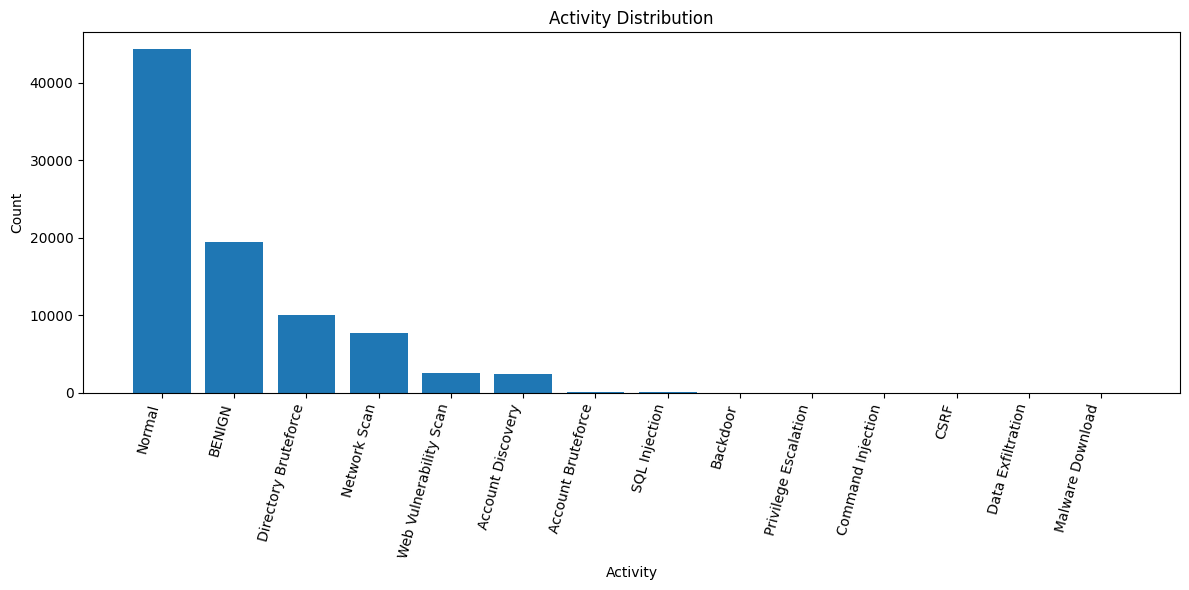


TARGET VARIABLE: 'Stage':
                    Count  Percentage
Stage                                
Benign              44258   51.052589
BENIGN              19454   22.440622
Reconnaissance      11909   13.737297
Establish Foothold   8604    9.924906
Lateral Movement     2451    2.827283
Data Exfiltration      15    0.017303


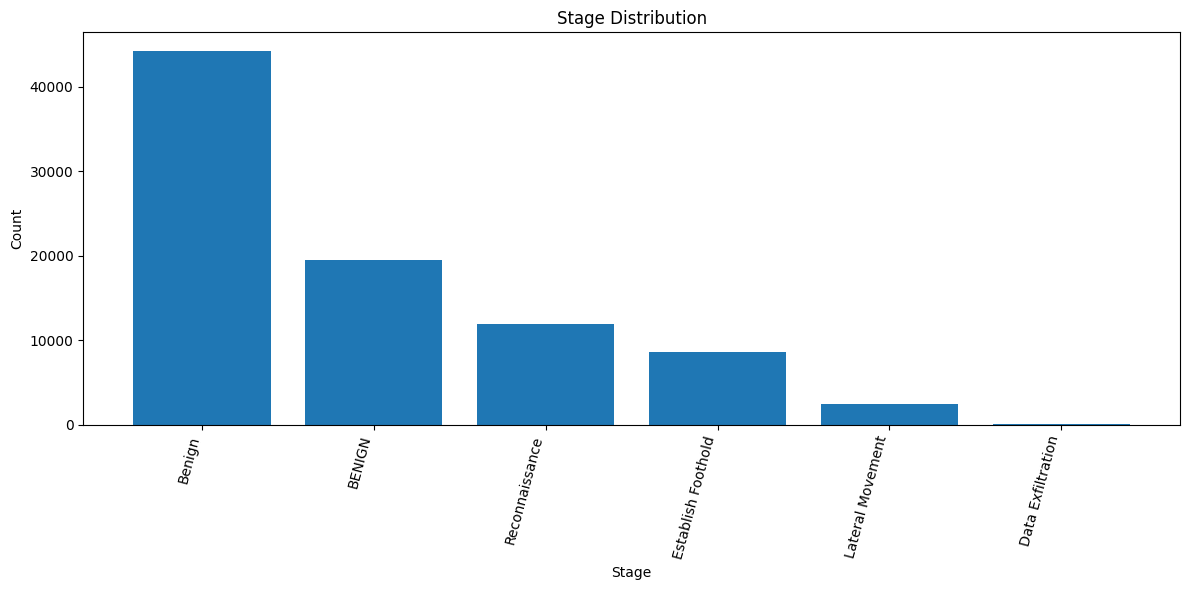

In [4]:
# Target variable
target_col_1 = 'Activity'
print(f"TARGET VARIABLE: '{target_col_1}':")
    
# Value counts, percentage
counts_1 = df[target_col_1].value_counts()
counts_per_1 = df[target_col_1].value_counts(normalize=True) * 100

result_1 = pd.DataFrame({
    "Count": counts_1,
    "Percentage": counts_per_1.round(6)
})
print(result_1)

# Visualization
plt.figure(figsize=(12, 6))
plt.bar(counts_1.index, counts_1.values)
plt.xticks(rotation=75, ha='right')
plt.xlabel("Activity")
plt.ylabel("Count")
plt.title("Activity Distribution")
plt.tight_layout()
plt.show()


# Target variable     
target_col_2 = 'Stage'
print(f"\nTARGET VARIABLE: '{target_col_2}':")

# Value counts
counts_2 = df[target_col_2].value_counts()
counts_per_2 = df[target_col_2].value_counts(normalize=True) * 100

result_2 = pd.DataFrame({
    "Count": counts_2,
    "Percentage": counts_per_2.round(6)
})
print(result_2)

# Visualization
plt.figure(figsize=(12, 6))
plt.bar(counts_2.index, counts_2.values)
plt.xticks(rotation=75, ha='right')
plt.xlabel("Stage")
plt.ylabel("Count")
plt.title("Stage Distribution")
plt.tight_layout()
plt.show()


In [5]:
df_merged = df.copy()
# Merge 'Normal' and 'BENIGN' into one 'Benign' category
# All other activities are considered 'Attack'
df_merged['Activity_Merged'] = df_merged['Activity'].apply(
    lambda x: 'Normal' if x in ['Normal', 'BENIGN'] else 'Attack'
)

print("Merged Activity distribution:")
print(df_merged['Activity_Merged'].value_counts())
print("\nPercentage distribution:")
print(df_merged['Activity_Merged'].value_counts(normalize=True) * 100)
df_merged = df_merged.drop(columns=['Stage', 'Activity'])

Merged Activity distribution:
Activity_Merged
Normal    63712
Attack    22979
Name: count, dtype: int64

Percentage distribution:
Activity_Merged
Normal    73.493212
Attack    26.506788
Name: proportion, dtype: float64



Original Stage distribution:
Stage
Benign                44258
BENIGN                19454
Reconnaissance        11909
Establish Foothold     8604
Lateral Movement       2451
Data Exfiltration        15
Name: count, dtype: int64

------------------------------------------------------------------------------------------
Merged Stage distribution:
Stage_Merged
Normal                63712
Reconnaissance        11909
Establish Foothold     8604
Lateral Movement       2451
Data Exfiltration        15
Name: count, dtype: int64

Percentage distribution:
Stage_Merged
Normal                73.49
Reconnaissance        13.74
Establish Foothold     9.92
Lateral Movement       2.83
Data Exfiltration      0.02
Name: proportion, dtype: float64


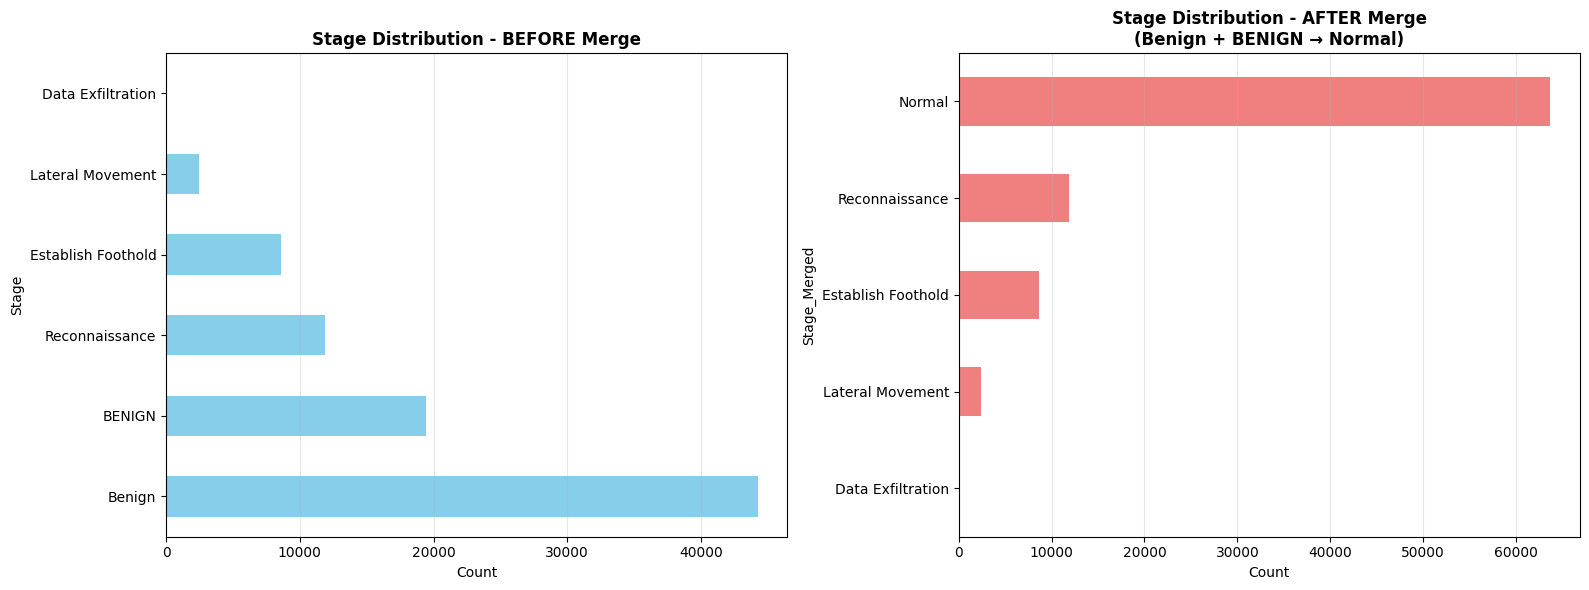

In [9]:
print("\nOriginal Stage distribution:")
print(df['Stage'].value_counts())

# Merge 'Benign' and 'BENIGN' into one 'Normal' category
# All other stages remain as is (Attack stages)
df['Stage_Merged'] = df['Stage'].apply(
    lambda x: 'Normal' if x in ['Benign', 'BENIGN'] else x
)

print("\n" + "-"*90)
print("Merged Stage distribution:")
merged_stage_counts = df['Stage_Merged'].value_counts()
print(merged_stage_counts)

print("\nPercentage distribution:")
merged_stage_pct = df['Stage_Merged'].value_counts(normalize=True) * 100
print(merged_stage_pct.round(2))

# Visualize: Comparison before and after merge
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Before merge
df['Stage'].value_counts().plot(kind='barh', ax=axes[0], color='skyblue')
axes[0].set_title('Stage Distribution - BEFORE Merge', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Count')
axes[0].grid(axis='x', alpha=0.3)

# After merge
df['Stage_Merged'].value_counts().sort_values().plot(kind='barh', ax=axes[1], color='lightcoral')
axes[1].set_title('Stage Distribution - AFTER Merge\n(Benign + BENIGN → Normal)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Count')
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()


PROTOCOL ANALYSIS BY STAGE


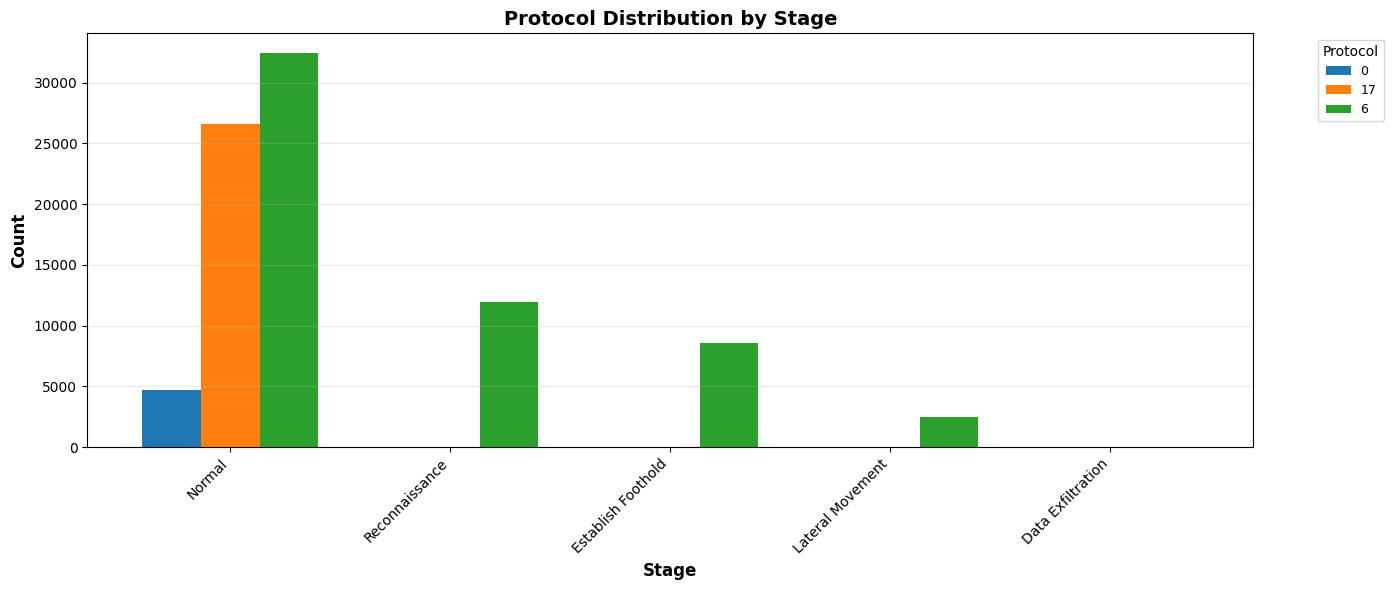

Protocol percentage by Stage_Merged:
Protocol              0      17      6 
Stage_Merged                           
Data Exfiltration   0.00   0.00  100.00
Establish Foothold  0.00   0.00  100.00
Lateral Movement    0.04   0.45   99.51
Normal              7.38  41.71   50.92
Reconnaissance      0.00   0.00  100.00


In [10]:
# Protocol Distribution by Stage_Merged
print("PROTOCOL ANALYSIS BY STAGE")

# Cross-tabulation: Stage_Merged vs Protocol
protocol_stage_cross = pd.crosstab(df['Stage_Merged'], df['Protocol'], margins=True)

stage_order = [
    "Normal",
    "Reconnaissance",
    "Establish Foothold",
    "Lateral Movement",
    "Data Exfiltration"
]

# All Protocol
protocols = df['Protocol'].unique().tolist()

# Crosstab
protocol_stage = pd.crosstab(df['Stage_Merged'], df['Protocol'])

# Reindex
protocol_stage = protocol_stage.reindex(stage_order)

# Get all protocol
protocol_stage_top = protocol_stage[protocols]


# Visualization
fig, ax = plt.subplots(figsize=(14, 6))

protocol_stage_top.plot(kind='bar', ax=ax, width=0.8)

ax.set_xlabel('Stage', fontsize=12, fontweight='bold')
ax.set_ylabel('Count', fontsize=12, fontweight='bold')
ax.set_title('Protocol Distribution by Stage', fontsize=14, fontweight='bold')
ax.legend(title='Protocol', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
ax.grid(axis='y', alpha=0.3)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Percentage distribution by Stage_Merged
print("Protocol percentage by Stage_Merged:")
protocol_stage_pct = pd.crosstab(df['Stage_Merged'], df['Protocol'], normalize='index') * 100
print(protocol_stage_pct[protocols].round(2))


IAT Statistics by Stage_Merged:
                    Flow IAT Mean  Flow IAT Std  Fwd IAT Mean  Bwd IAT Mean
Stage_Merged                                                               
Data Exfiltration       289736.00     657867.10     459000.10     815968.41
Establish Foothold       45748.15      77587.77     108036.44      38562.97
Lateral Movement        181107.28     246441.12     246188.13     175820.37
Normal                 2719367.55    1407372.46    2559220.51     857937.48
Reconnaissance           64644.43      49577.45      60773.10      29638.08

------------------------------------------------------------------------------------------
Detailed IAT Analysis:

Data Exfiltration:
  Flow IAT Mean       : Mean =    289736.00, Std =   1091946.80
  Flow IAT Std        : Mean =    657867.10, Std =   2547656.95
  Fwd IAT Mean        : Mean =    459000.10, Std =   1777609.35
  Bwd IAT Mean        : Mean =    815968.41, Std =   3160221.82

Establish Foothold:
  Flow IAT Mean       :

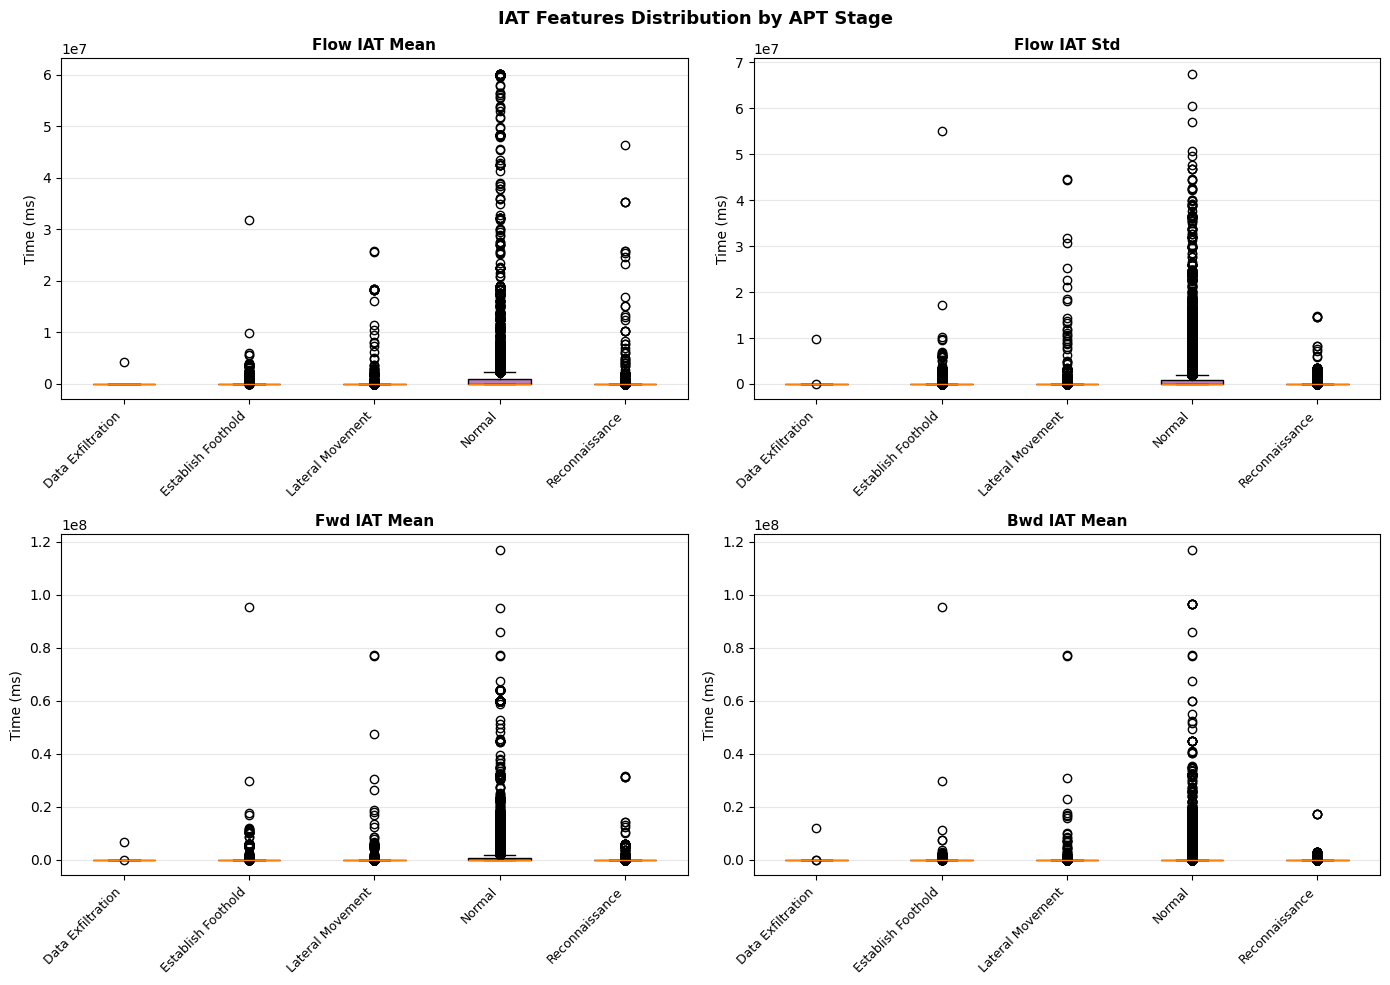

In [12]:
# IAT (Inter-Arrival Time) Analysis

iat_features = ['Flow IAT Mean', 'Flow IAT Std', 'Fwd IAT Mean', 'Bwd IAT Mean']
iat_features = [f for f in iat_features if f in df.columns]

print("\nIAT Statistics by Stage_Merged:")
iat_stats = df.groupby('Stage_Merged')[iat_features].mean()
print(iat_stats.round(2))

# Detailed analysis
print("\n" + "-"*90)
print("Detailed IAT Analysis:")
for stage in sorted(df['Stage_Merged'].unique()):
    print(f"\n{stage}:")
    stage_data = df[df['Stage_Merged'] == stage]
    for feature in iat_features:
        mean_val = stage_data[feature].mean()
        std_val = stage_data[feature].std()
        print(f"  {feature:20s}: Mean = {mean_val:12.2f}, Std = {std_val:12.2f}")

# Visualize: Boxplot for IAT features
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, feature in enumerate(iat_features):
    ax = axes[idx]
    
    # Create boxplot for each Stage_Merged
    data_for_box = [df[df['Stage_Merged'] == stage][feature].dropna().values for stage in sorted(df['Stage_Merged'].unique())]
    bp = ax.boxplot(data_for_box, tick_labels=sorted(df['Stage_Merged'].unique()), patch_artist=True)
    
    # Color the boxes with gradient
    colors = plt.cm.Set3(np.linspace(0, 1, len(df['Stage_Merged'].unique())))
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
    
    ax.set_title(f'{feature}', fontweight='bold', fontsize=11)
    ax.set_ylabel('Time (ms)')
    ax.grid(axis='y', alpha=0.3)
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right', fontsize=9)

plt.suptitle('IAT Features Distribution by APT Stage', 
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [16]:
import warnings
warnings.filterwarnings("ignore")

# Calculate correlation of all features with target variable

# Select only numeric columns
numeric_df = df.select_dtypes(include=[np.number])

# Calculate correlation with target variable
# First, encode the target variable
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
target_encoded = le.fit_transform(df['Stage_Merged'])

# Calculate correlation coefficient for each feature
correlation_with_target = {}
for col in numeric_df.columns:
    corr = np.corrcoef(numeric_df[col].fillna(numeric_df[col].mean()), target_encoded)[0, 1]
    correlation_with_target[col] = abs(corr) if not np.isnan(corr) else 0

# Sort by absolute correlation value (descending)
sorted_features = sorted(correlation_with_target.items(), key=lambda x: x[1], reverse=True)

print("\nTop 20 Features by Correlation with Target Variable:")
print("-" * 70)
print(f"{'Rank':<6} {'Feature':<40} {'Abs Correlation':<15}")
print("-" * 70)

for idx, (feature, corr) in enumerate(sorted_features[:20], 1):
    print(f"{idx:<6} {feature:<40} {corr:<15.4f}")

# Select top 15 features for detailed analysis
top_15_features = [feature for feature, _ in sorted_features[:15]]
print("\n\nTop 15 Features Selected for Correlation Analysis:")
for idx, feature in enumerate(top_15_features, 1):
    print(f"{idx:2d}. {feature}")

# Create a copy of the dataframe with only top features
df_top_features = df[top_15_features].copy()

# Calculate correlation matrix
correlation_matrix = df_top_features.corr()


Top 20 Features by Correlation with Target Variable:
----------------------------------------------------------------------
Rank   Feature                                  Abs Correlation
----------------------------------------------------------------------
1      FIN Flag Count                           0.2801         
2      Src Port                                 0.1414         
3      Bwd Packets/s                            0.1384         
4      Flow Packets/s                           0.1141         
5      Protocol                                 0.0670         
6      SYN Flag Count                           0.0655         
7      Fwd Packet Length Std                    0.0627         
8      Flow Duration                            0.0594         
9      Fwd IAT Total                            0.0568         
10     Packet Length Min                        0.0502         
11     Bwd PSH Flags                            0.0485         
12     PSH Flag Count               

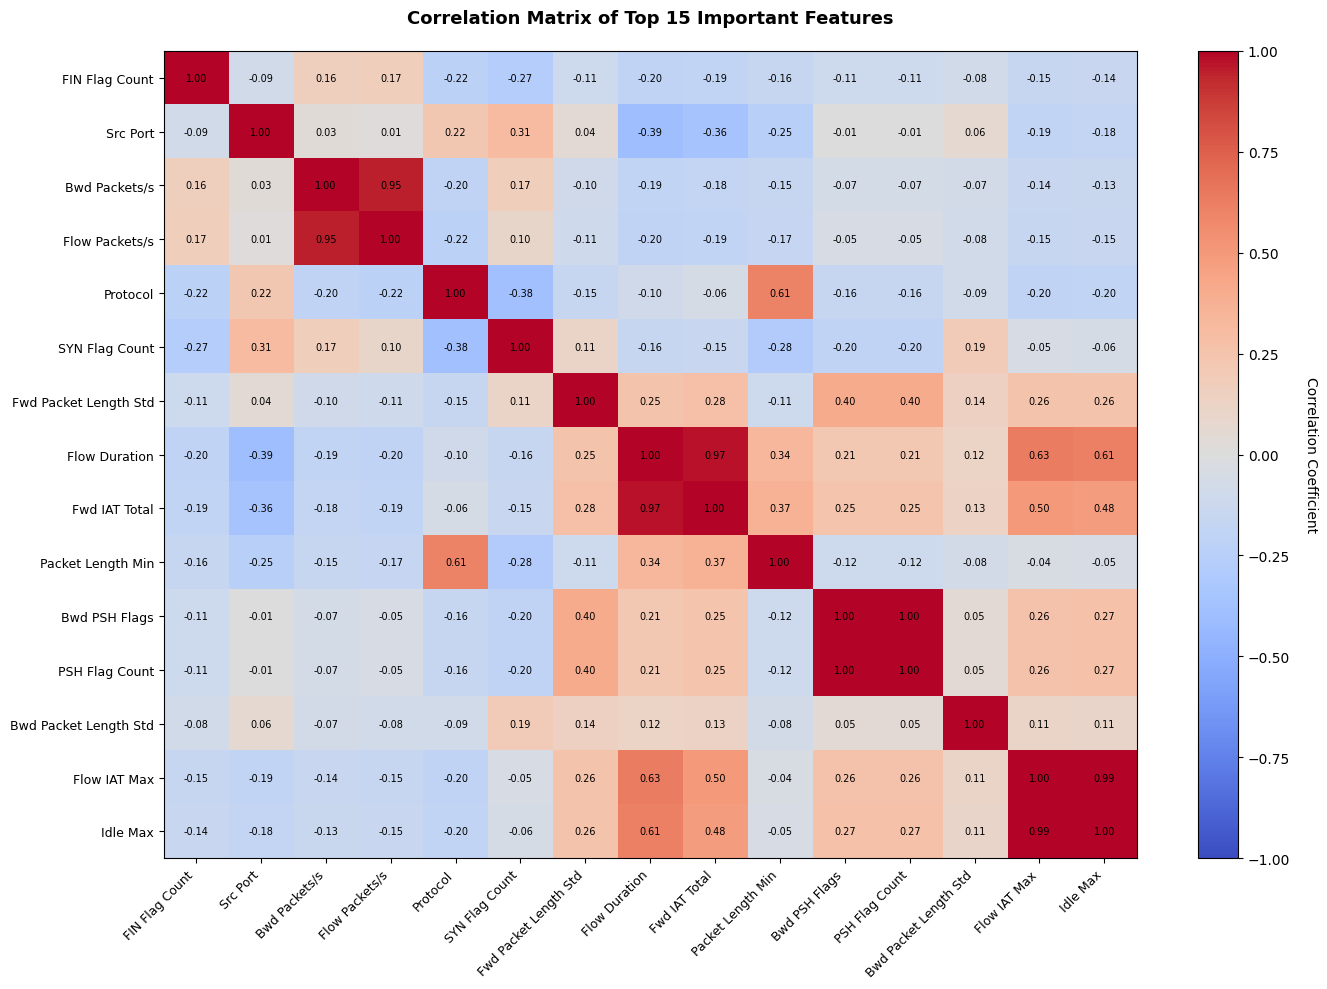

In [17]:
# Visualize: Heatmap of Correlation Matrix
fig, ax = plt.subplots(figsize=(14, 10))

# Create heatmap
im = ax.imshow(correlation_matrix, cmap='coolwarm', aspect='auto', vmin=-1, vmax=1)

# Set ticks and labels
ax.set_xticks(np.arange(len(correlation_matrix.columns)))
ax.set_yticks(np.arange(len(correlation_matrix.columns)))
ax.set_xticklabels(correlation_matrix.columns, rotation=45, ha='right', fontsize=9)
ax.set_yticklabels(correlation_matrix.columns, fontsize=9)

# Add colorbar
cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Correlation Coefficient', rotation=270, labelpad=20)

# Add correlation values in cells
for i in range(len(correlation_matrix.columns)):
    for j in range(len(correlation_matrix.columns)):
        text = ax.text(j, i, f'{correlation_matrix.iloc[i, j]:.2f}',
                      ha="center", va="center", color="black", fontsize=7)

ax.set_title('Correlation Matrix of Top 15 Important Features', 
             fontsize=13, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

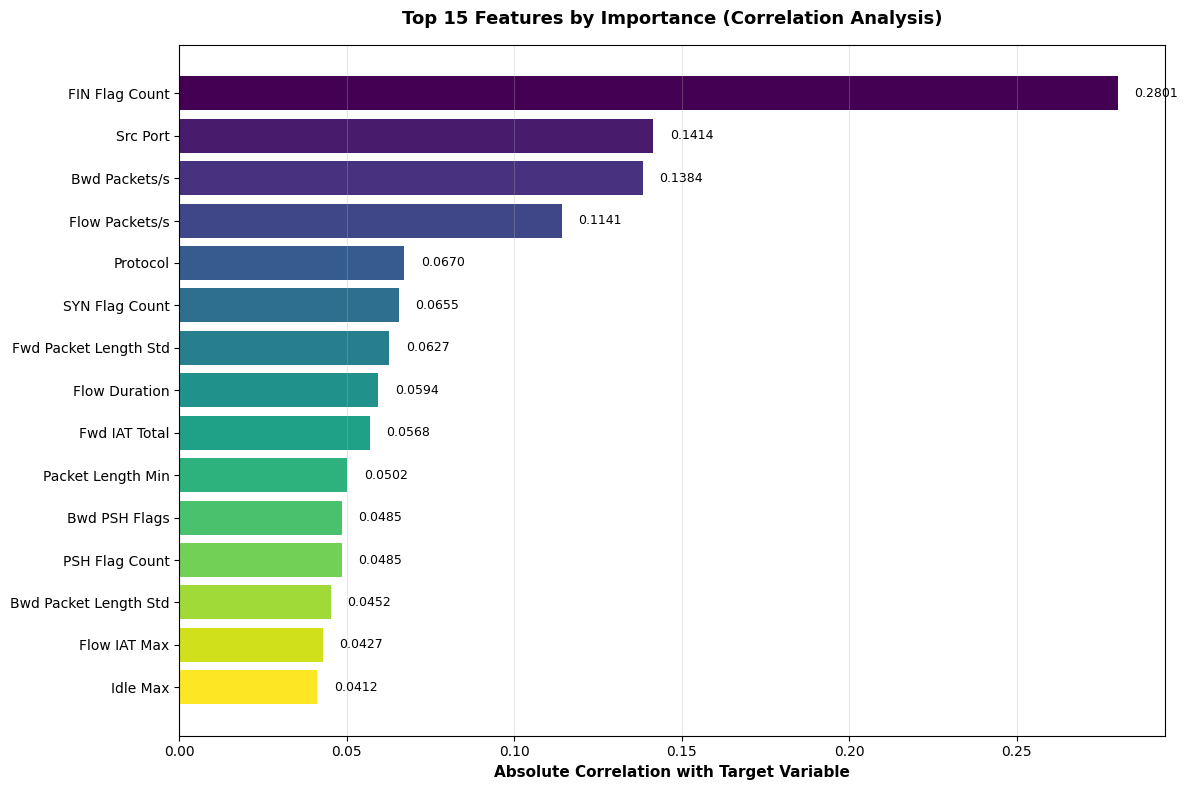

In [19]:
# Visualize: Bar chart of Feature Importance (Correlation with Target)
fig, ax = plt.subplots(figsize=(12, 8))

features = [f[0] for f in sorted_features[:15]]
correlations = [f[1] for f in sorted_features[:15]]

# Create bar chart with gradient colors
colors_grad = plt.cm.viridis(np.linspace(0, 1, len(features)))
bars = ax.barh(range(len(features)), correlations, color=colors_grad)

# Customize the plot
ax.set_yticks(range(len(features)))
ax.set_yticklabels(features, fontsize=10)
ax.set_xlabel('Absolute Correlation with Target Variable', fontsize=11, fontweight='bold')
ax.set_title('Top 15 Features by Importance (Correlation Analysis)', 
             fontsize=13, fontweight='bold', pad=15)
ax.grid(axis='x', alpha=0.3)

# Add value labels on bars
for idx, (bar, corr) in enumerate(zip(bars, correlations)):
    ax.text(corr + 0.005, idx, f'{corr:.4f}', va='center', fontsize=9)

# Reverse y-axis to show best features on top
ax.invert_yaxis()
plt.tight_layout()
plt.show()